In [4]:
import pandas as pd
csv = '..//datasets/creditcard.csv'
df = pd.read_csv(csv)
print(df.head())
print(df.shape)
print("hello")
print(df.info())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

snapshot of missing data 

In [5]:
df.isnull().sum().sort_values(ascending=False)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

identifying and handling missing data


In [6]:
df.isnull().sum().sort_values(ascending=False).head()

Time    0
V1      0
V2      0
V3      0
V4      0
dtype: int64

count number of 1s and 0s create percentage 

In [7]:
# compare class percentages clearly
class_counts = df["Class"].value_counts().sort_index()
class_percentages = (class_counts / len(df)) * 100

print("Class counts:")
print(class_counts)
print()
print("Class percentages:")
print(class_percentages)

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.827251
1     0.172749
Name: count, dtype: float64


exploratary analysis

In [8]:
# split fraud and normal
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

print("Fraud rows:", len(fraud))
print("Normal rows:", len(normal))

Fraud rows: 492
Normal rows: 284315


In [9]:
# compare Amount
print("Amount summary for fraud:")
print(fraud["Amount"].describe())
print()
print("Amount summary for normal:")
print(normal["Amount"].describe())

Amount summary for fraud:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Amount summary for normal:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [10]:
# compare Time
print("Time summary for fraud:")
print(fraud["Time"].describe())
print()
print("Time summary for normal:")
print(normal["Time"].describe())

Time summary for fraud:
count       492.000000
mean      80746.806911
std       47835.365138
min         406.000000
25%       41241.500000
50%       75568.500000
75%      128483.000000
max      170348.000000
Name: Time, dtype: float64

Time summary for normal:
count    284315.000000
mean      94838.202258
std       47484.015786
min           0.000000
25%       54230.000000
50%       84711.000000
75%      139333.000000
max      172792.000000
Name: Time, dtype: float64


In [11]:
# mean and median comparison for interpretable columns
print("Fraud mean Amount:", fraud["Amount"].mean())
print("Normal mean Amount:", normal["Amount"].mean())
print()
print("Fraud median Amount:", fraud["Amount"].median())
print("Normal median Amount:", normal["Amount"].median())
print()
print("Fraud mean Time:", fraud["Time"].mean())
print("Normal mean Time:", normal["Time"].mean())
print()
print("Fraud median Time:", fraud["Time"].median())
print("Normal median Time:", normal["Time"].median())

Fraud mean Amount: 122.21132113821139
Normal mean Amount: 88.29102242231328

Fraud median Amount: 9.25
Normal median Amount: 22.0

Fraud mean Time: 80746.80691056911
Normal mean Time: 94838.20225805884

Fraud median Time: 75568.5
Normal median Time: 84711.0


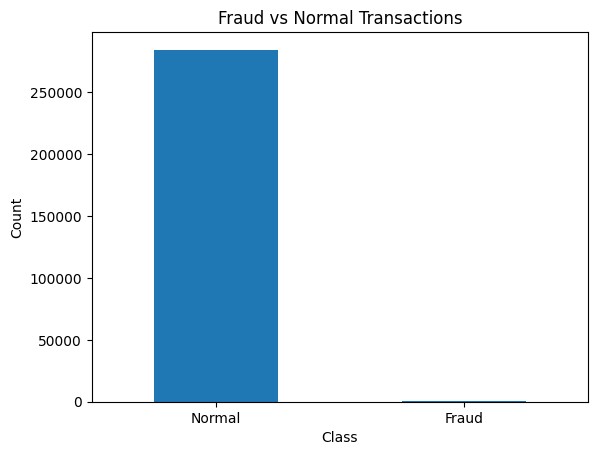

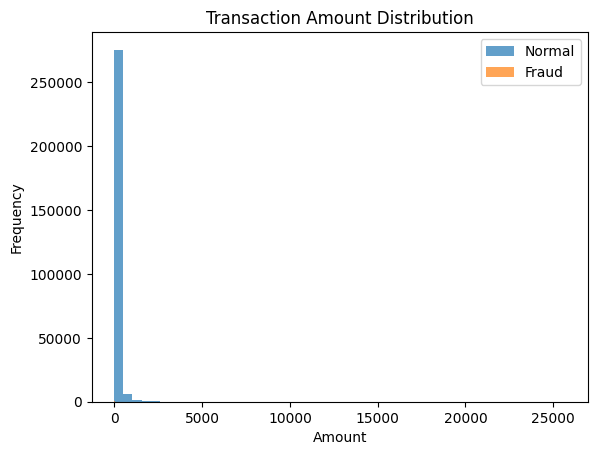

In [12]:
import matplotlib.pyplot as plt
# class distribution plot
class_counts.plot(kind="bar")
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Normal", "Fraud"], rotation=0)
plt.show()
# amount distribution
plt.hist(normal["Amount"], bins=50, alpha=0.7, label="Normal")
plt.hist(fraud["Amount"], bins=50, alpha=0.7, label="Fraud")
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

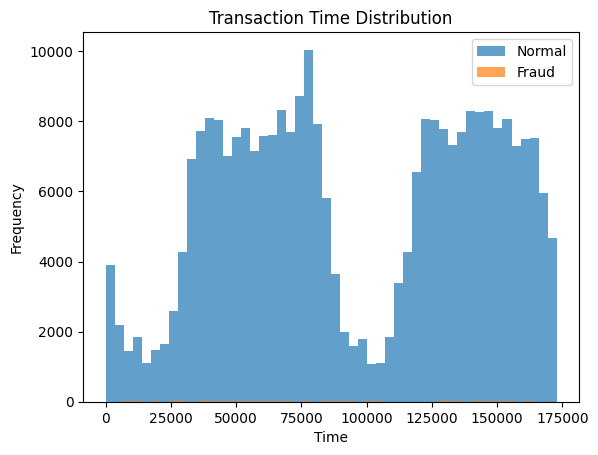

In [13]:
# time distribution
plt.hist(normal["Time"], bins=50, alpha=0.7, label="Normal")
plt.hist(fraud["Time"], bins=50, alpha=0.7, label="Fraud")
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.legend()
plt.show()

C:\Users\summe\AppData\Local\Temp\ipykernel_35420\3110916440.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal["Amount"], fraud["Amount"]], labels=["Normal", "Fraud"])


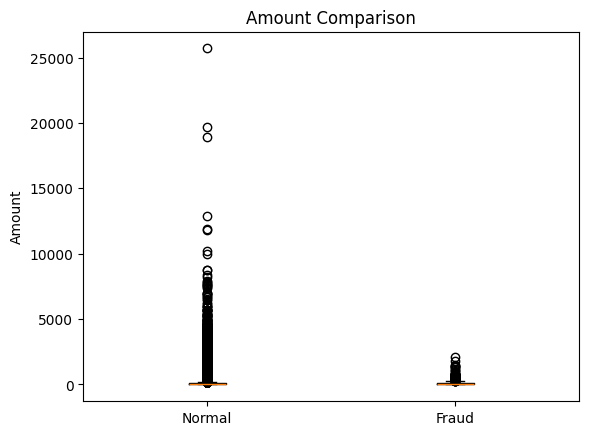

In [14]:
# boxplot for Amount
plt.boxplot([normal["Amount"], fraud["Amount"]], labels=["Normal", "Fraud"])
plt.title("Amount Comparison")
plt.ylabel("Amount")
plt.show()

C:\Users\summe\AppData\Local\Temp\ipykernel_35420\1637112264.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal["Time"], fraud["Time"]], labels=["Normal", "Fraud"])


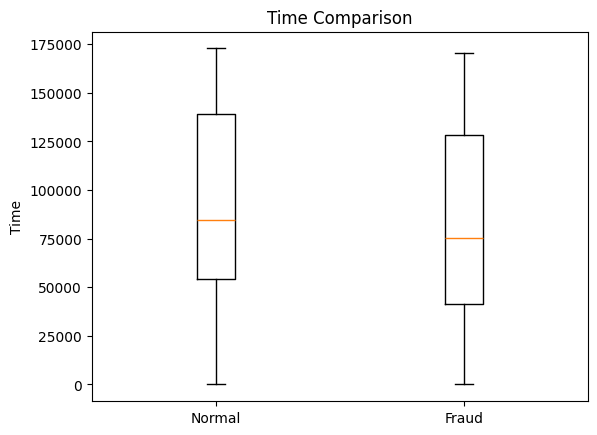

In [15]:
# boxplot for Time
plt.boxplot([normal["Time"], fraud["Time"]], labels=["Normal", "Fraud"])
plt.title("Time Comparison")
plt.ylabel("Time")
plt.show()

pick target 

In [16]:
target = df["Class"]

pick features


In [17]:
X = df.drop("Class", axis=1)
y = df["Class"]

Check x and y features

In [18]:
rowsOfX = X.shape[0]
print("Number of rows in X:", rowsOfX)
rowsOfY = y.shape[0]
print("Number of rows in y:", rowsOfY)

Number of rows in X: 284807
Number of rows in y: 284807


split into training and testing data 

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

verify split

In [20]:
rowsOfTrains = X_train.shape[0] + y_train.shape[0]
print("Number of rows in X_train:", X_train.shape[0])
print("Number of rows in y_train:", y_train.shape[0])
print("Total rows in train set:", rowsOfTrains)
rowsOfTests = X_test.shape[0] + y_test.shape[0]
print("Number of rows in X_test:", X_test.shape[0])
print("Number of rows in y_test:", y_test.shape[0])
print("Total rows in test set:", rowsOfTests)

Number of rows in X_train: 227845
Number of rows in y_train: 227845
Total rows in train set: 455690
Number of rows in X_test: 56962
Number of rows in y_test: 56962
Total rows in test set: 113924


how many 0s and 1s are in y_train
how many 0s and 1s are in y_test

In [22]:

print("y_train class distribution:")
print(y_train.value_counts())
print("y_test class distribution:")
print(y_test.value_counts())


y_train class distribution:
Class
0    227451
1       394
Name: count, dtype: int64
y_test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_time = StandardScaler()
scaler_amount = StandardScaler()
time = X_train["Time"].values.reshape(-1, 1)
amount = X_train["Amount"].values.reshape(-1, 1)
X_train["Time"] = scaler_time.fit_transform(time)
X_train["Amount"] = scaler_amount.fit_transform(amount)
time_test = X_test["Time"].values.reshape(-1, 1)
amount_test = X_test["Amount"].values.reshape(-1, 1)
X_test["Time"] = scaler_time.transform(time_test)
X_test["Amount"] = scaler_amount.transform(amount_test)

first model

In [28]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.72      0.78        98

    accuracy                           1.00     56962
   macro avg       0.93      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56852    12]
 [   27    71]]
